## Academics Topic Overview Analysis

This notebook analyzes YouTube comments and videos discussing **academics (faculty, curriculum, exams, research)** across Indian universities. It follows the same technique set used in the Placement, Fees, Hostel, and Student Experience analyses (cleaning, TF, TF-IDF, word cloud, engagement, sentiment, topic modeling, university-wise and trend analysis), and adds an **academics-specific layer**: tagging comments into academics aspects (faculty/teaching quality, curriculum/syllabus, exams/grading, research/labs, placements, workload/pressure, course/branch choice, rank/admission cutoff), a dedicated **faculty praise-vs-criticism signal detector**, an **exam/grading difficulty perception detector**, and a **video-type classification** (Review, Comparison/Ranking, Vlog/Campus Tour, Faculty-focused, Placement/Fee Info) on the video-level dataset.

### TECHNIQUE 1: Data Cleaning & Preprocessing

#### Clean noisy text

##### Why this Technique was Used

Data preprocessing helps in:
Removing noisy and irrelevant information.
Improving text consistency.
Preparing data for frequency analysis, sentiment analysis, and topic modeling.
Reducing errors in downstream NLP tasks.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import re
import os

# Set the plotting backend to inline explicitly (works even if this
# notebook is restarted, run cell-by-cell, or run out of order) so every
# plt.show() below actually renders a chart instead of doing nothing.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import matplotlib.pyplot as plt

# Every chart in this notebook is also saved as a standalone PNG here,
# in addition to rendering inline.
os.makedirs("figures", exist_ok=True)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    "india_universities_academics_comments.csv"
)

df.head()

,comment_id,thread_id,parent_comment_id,video_id,video_title,channel_name,university_name,category,keyword,author_name,...,comment_month,likes,reply_count,is_reply,comment_type,comment_length,word_count,contains_question,contains_url,contains_emoji
0,UgwM7_bgWEmLeTx4mkB4AaABAg,UgwM7_bgWEmLeTx4mkB4AaABAg,NaN,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,IIT Delhi,academics,faculty review,@ManjuDevi-g3c3g,...,9,5,0,False,parent,58,13,False,False,True
1,UgyQ_E_s3KVMz6PKQbp4AaABAg,UgyQ_E_s3KVMz6PKQbp4AaABAg,NaN,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,IIT Delhi,academics,faculty review,@antikabaug,...,9,3,0,False,parent,16,3,False,False,True
2,UgybIr5fTGCZEIPYBJh4AaABAg,UgybIr5fTGCZEIPYBJh4AaABAg,NaN,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,IIT Delhi,academics,faculty review,@sachinrajak5435,...,1,8,0,False,parent,68,13,False,False,False
3,Ugwc9a2IiEcjP-1gR-N4AaABAg,Ugwc9a2IiEcjP-1gR-N4AaABAg,NaN,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,IIT Delhi,academics,faculty review,@KishanSingh-x9o,...,6,1,0,False,parent,22,5,False,False,False
4,UgzWTLsfMfps8qZPWt94AaABAg,UgzWTLsfMfps8qZPWt94AaABAg,NaN,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,IIT Delhi,academics,faculty review,@zero2value26,...,6,7,0,False,parent,37,7,False,False,False


In [2]:
# ==========================================
# Missing Value Analysis
# ==========================================

df.isnull().sum()

comment_id               0
thread_id                0
parent_comment_id    30469
video_id                 0
video_title              0
channel_name             0
university_name          0
category                 0
keyword                  0
author_name              0
comment_text             4
published_at             0
comment_date             0
comment_year             0
comment_month            0
likes                    0
reply_count              0
is_reply                 0
comment_type             0
comment_length           0
word_count               0
contains_question        0
contains_url             0
contains_emoji           0
dtype: int64

In [3]:
# ==========================================
# Remove Empty Comments
# ==========================================

df = df.dropna(
    subset=["comment_text"]
)

print("Rows after cleaning:", len(df))

Rows after cleaning: 51785


In [4]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs only
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,"Vaa sir ye to vhi baat ho gyi ""EAT 5 STAR DO N...","Vaa sir ye to vhi baat ho gyi ""EAT 5 STAR DO N..."
1,Best efforts 😂😂😂,Best efforts 😂😂😂
2,Kurur to abhi Dean of Academic hai\n\nBahut hi...,Kurur to abhi Dean of Academic hai Bahut hi Ac...
3,Bawa viral ho gay guru,Bawa viral ho gay guru
4,Bhaiya your jee story par video banao,Bhaiya your jee story par video banao


In [5]:
# ==========================================
# Duplicate Analysis
# ==========================================

duplicates = df.duplicated(
    subset=["comment_id"]
).sum()

print(
    "Duplicate Comments:",
    duplicates
)

Duplicate Comments: 0


In [6]:
# ==========================================
# Dataset Summary
# ==========================================

print("Universities:",
      df["university_name"].nunique())

print("Videos:",
      df["video_id"].nunique())

print("Comments:",
      len(df))

Universities: 99
Videos: 893
Comments: 51785


# 4.2 Comment Length Analysis

## Objective

Comment length analysis was performed to understand the depth and engagement level of discussions related to academics. Longer comments generally indicate detailed personal accounts of faculty quality, exam difficulty, or research opportunities, whereas shorter comments often represent quick reactions ('faculty is good', 'is CSE better here?').

#### 1. Calculate Comment Length

In [7]:
# ==========================================
# Comment Length Analysis
# ==========================================

df["comment_length"] = (
    df["clean_comment"]
    .str.len()
)

df[
    [
        "clean_comment",
        "comment_length"
    ]
].head()

,clean_comment,comment_length
0,"Vaa sir ye to vhi baat ho gyi ""EAT 5 STAR DO N...",58
1,Best efforts 😂😂😂,16
2,Kurur to abhi Dean of Academic hai Bahut hi Ac...,65
3,Bawa viral ho gay guru,22
4,Bhaiya your jee story par video banao,37


#### 2. Basic Statistics

In [8]:
# ==========================================
# Length Statistics
# ==========================================

print(
    df["comment_length"]
    .describe()
)

count    51785.000000
mean        66.438679
std        106.716158
min          0.000000
25%         21.000000
50%         41.000000
75%         75.000000
max       4076.000000
Name: comment_length, dtype: float64


#### 3. Average Length

In [9]:
print(
    "Average Comment Length:",
    round(
        df["comment_length"].mean(),
        2
    )
)

Average Comment Length: 66.44


#### 4. Histogram

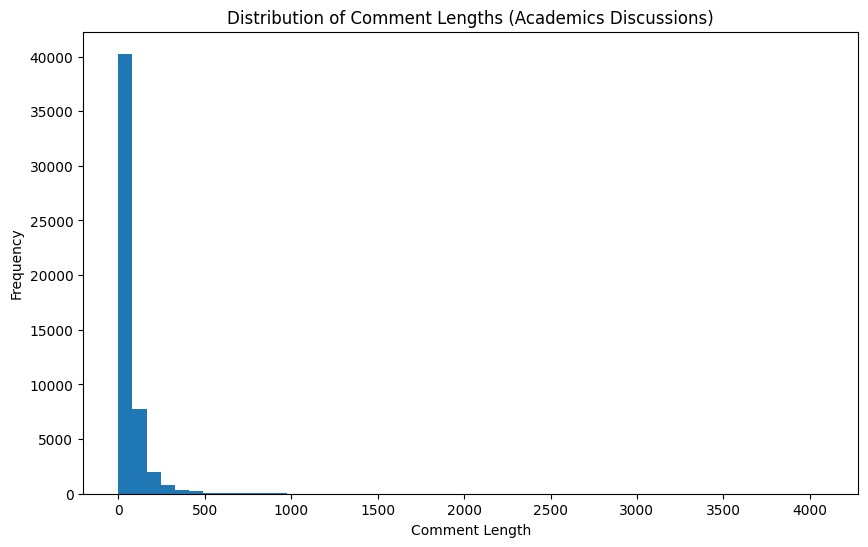

In [10]:
plt.figure(
    figsize=(10,6)
)

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (Academics Discussions)"
)

plt.xlabel(
    "Comment Length"
)

plt.ylabel(
    "Frequency"
)

plt.savefig("figures/01_distribution_of_comment_lengths_academics_discussions.png", dpi=150, bbox_inches="tight")
plt.show()

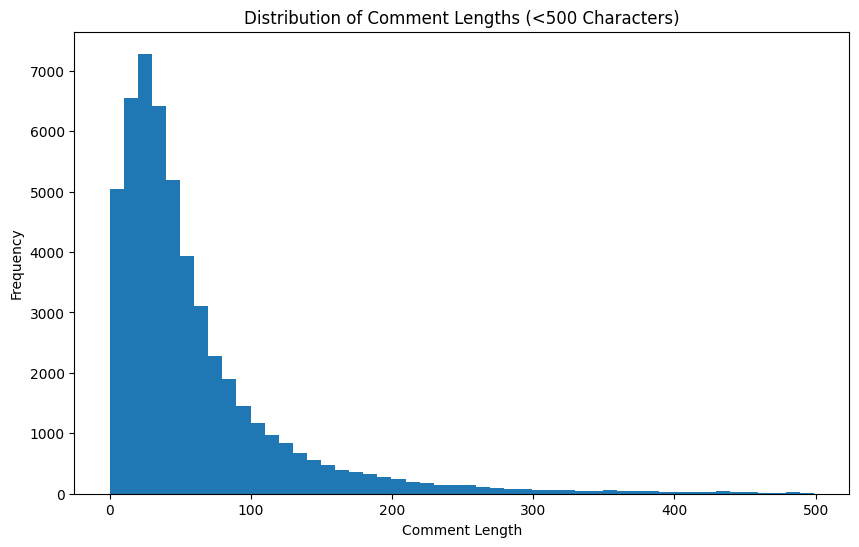

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df["comment_length"] < 500]["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (<500 Characters)"
)

plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.savefig("figures/02_distribution_of_comment_lengths_500_characters.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation of Comment Length Distribution

The histogram is right-skewed, with the mean comment length (~66 characters) sitting well above the median (41 characters) — a similar shape to the Hostel and Student Experience datasets. Most academics comments are short reactions or one-line questions ('faculty is good', 'is CSE better here?'), while a smaller share of long comments contain detailed personal accounts of faculty quality, research opportunities, or exam pressure.

#### 5. Box Plot

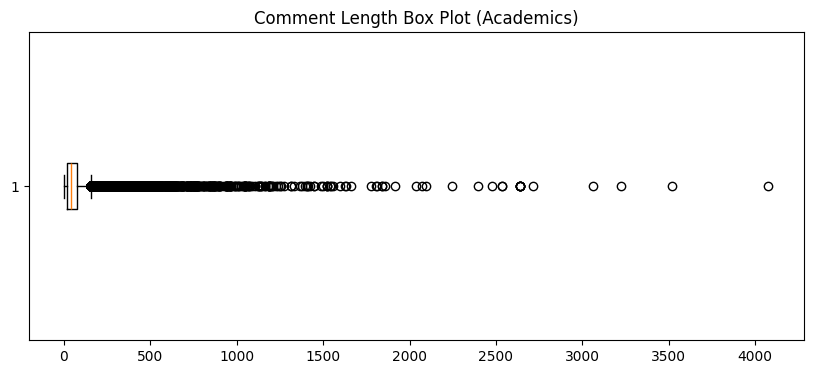

In [12]:
plt.figure(
    figsize=(10,4)
)

plt.boxplot(
    df["comment_length"],
    vert=False
)

plt.title(
    "Comment Length Box Plot (Academics)"
)

plt.savefig("figures/03_comment_length_box_plot_academics.png", dpi=150, bbox_inches="tight")
plt.show()

Box = Middle 50% of comments (IQR)

Orange line = Median comment length

Dots = Outliers (long, detailed comments)

#### 6. University-wise Average Comment Length

In [13]:
avg_length = (

    df.groupby(
        "university_name"
    )["comment_length"]

    .mean()

    .sort_values(
        ascending=False
    )

    .head(15)
)

avg_length

university_name
IIIT Kottayam             165.639037
IIM Shillong              107.363636
PES University            105.982456
Jain University           105.192182
IIM Indore                 98.884876
Christ University          97.958071
IIM Bangalore              96.710256
BITS Goa                   88.891753
IIM Kozhikode              83.295597
Graphic Era University     81.871389
IIM Ranchi                 81.720930
IIM Udaipur                81.527273
IIIT Jabalpur              81.525000
NMIMS University           81.201471
UPES Dehradun              79.895745
Name: comment_length, dtype: float64

#### 7. Visualization

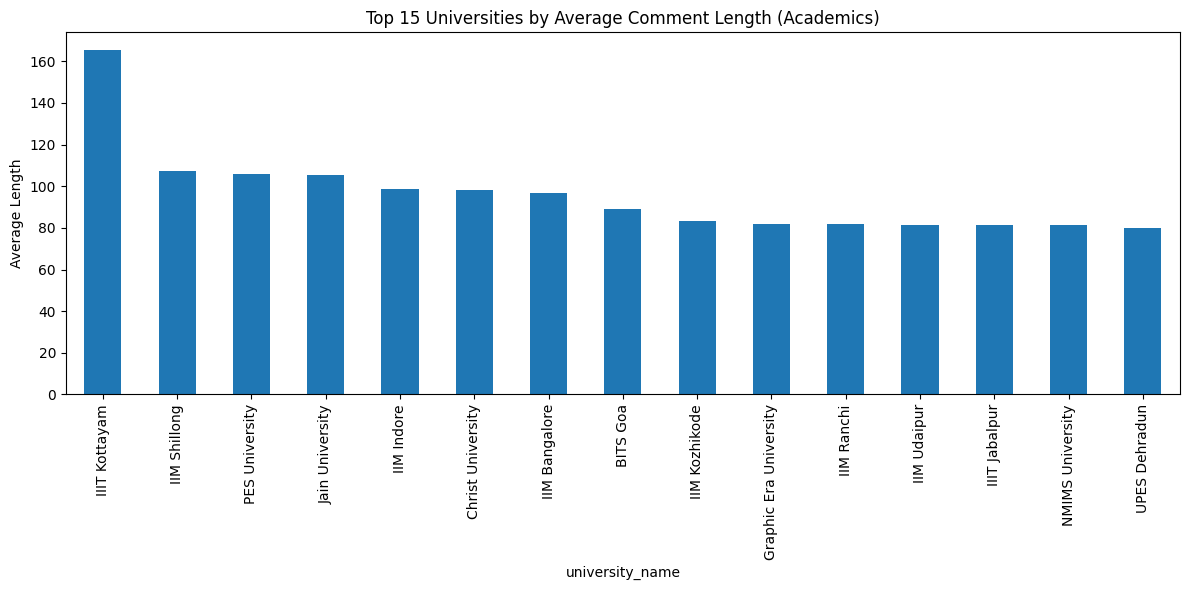

In [14]:
plt.figure(
    figsize=(12,6)
)

avg_length.plot(
    kind="bar"
)

plt.title(
    "Top 15 Universities by Average Comment Length (Academics)"
)

plt.ylabel(
    "Average Length"
)

plt.tight_layout()
plt.savefig("figures/04_top_15_universities_by_average_comment_length_academics.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

Comment length analysis revealed the overall depth of engagement in academics discussions. IIIT Kottayam sits far above every other university (~166 characters average, roughly 2.5x the overall mean), followed by IIM Shillong, PES University, and Jain University — these are threads where commenters write out detailed, multi-line personal accounts of academic life rather than one-word reactions.

# 3 Term Frequency Analysis

## Objective

Term Frequency (TF) analysis was performed to identify the most frequently occurring words in academics-related comments, to understand the dominant themes (branch, placement, fees, exam, faculty, etc.) that students and prospective students discuss.

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

True

#### Master Stopword List

A plain English stopword list alone leaves a lot of noise in Hinglish YouTube comments — filler words (hai, sir, please, kya, bro, bhai, bhi, nhi, liye), YouTube-generic words (video, subscribe, comment), and topic-generic words that appear in almost every comment by definition (college, university, student). These are combined into one master stopword list, reused across TF, TF-IDF, word cloud, bigram, and LDA topic modeling below so results stay consistent.

In [16]:
# ==========================================
# Master Stopword List (reused across all NLP techniques below)
# ==========================================

# Hindi / Hinglish filler words commonly seen in YouTube comments
hinglish_stopwords = {
    "hai","ho","h","ka","ki","ke","ko","se","me","mai","mein",
    "aur","ya","ye","yeh","wo","woh","is","us","to","toh","bhi","nhi",
    "nahi","liye","kar","karo","kr","krna","krne","hua","huaa",
    "mujhe","mera","mere","meri","apna","apni","apne","acha","accha",
    "sirf","fir","phir","ab","sab","kuch","bahut","bohot","kya","kese","kaise",
    "kon","kaun","kab","kaha","kahan","wah","agar","koi","uske","uska",
    "iske","iska","kro","kro","hoga","hogi","honge","tha","thi","the",
    "bro","bhai","bhaiya","sir","maam","yaar","dost","plz","pls",
    "chahiye","milega","milegi","kitna","kitni","kaisa","kaisi"
}

# YouTube / engagement-generic words
youtube_stopwords = {
    "video","videos","channel","watch","watched","subscribe",
    "subscribed","like","liked","comment","comments","share","link",
    "please","thanks","thank","good","nice","great","best"
}

# Topic-generic words — appear in almost every comment by definition,
# so they crowd out the words that actually differentiate one comment from another
topic_generic_stopwords = {
    "college","colleges","university","universities","student","students",
    "get","got","one","also","even","much","many","really","know",
    "admission","year","years"
}

stop_words = (
    set(stopwords.words("english"))
    | hinglish_stopwords
    | youtube_stopwords
    | topic_generic_stopwords
)

print("Total stopwords in use:", len(stop_words))

Total stopwords in use: 319


#### Create Analysis Text Column

In [17]:
from collections import Counter
import re

def preprocess_tf(text):

    text = str(text).lower()

    words = re.findall(
        r"\b[a-z]+\b",
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

df["tokens"] = df["clean_comment"].apply(preprocess_tf)

In [18]:
all_words = []

for words in df["tokens"]:
    all_words.extend(words)

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_words

,Word,Frequency
0,iit,2774
1,cse,1954
2,placement,1601
3,nit,1524
4,fees,1218
5,campus,1110
6,better,1105
7,btech,1063
8,hostel,1062
9,jee,1052


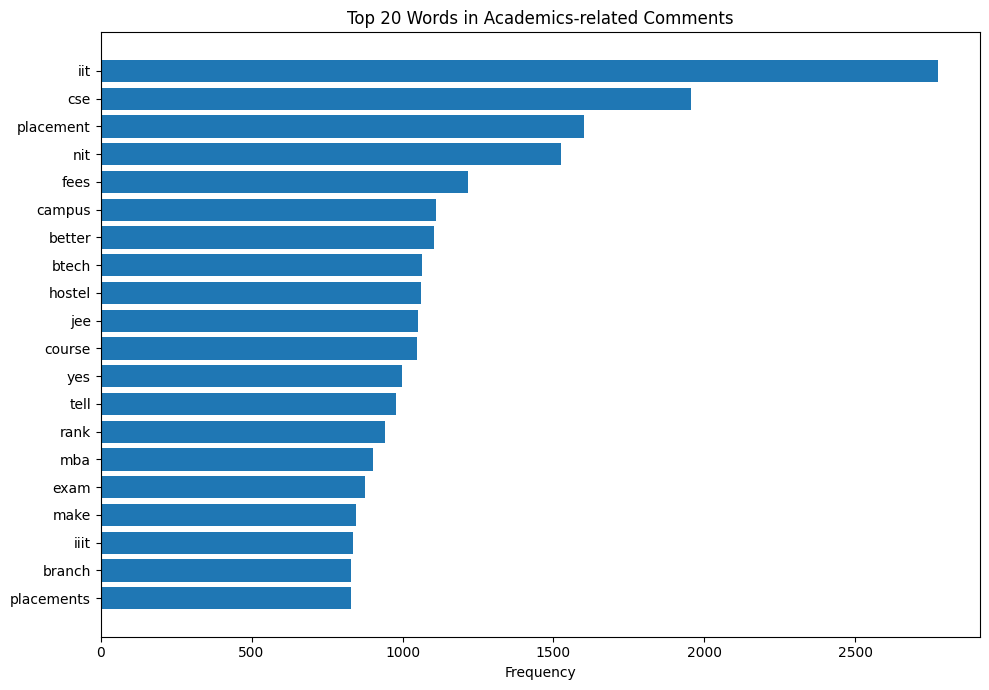

In [19]:
plt.figure(figsize=(10,7))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Top 20 Words in Academics-related Comments")
plt.xlabel("Frequency")

plt.tight_layout()
plt.savefig("figures/05_top_20_words_in_academics_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Interpretation

Words like *iit, cse, placement, nit, fees, campus, better, btech, hostel, jee, course, rank, mba, exam, branch* dominate — even though this dataset was collected specifically around "faculty review" videos, the actual comment vocabulary looks almost identical to the Hostel and Student Experience datasets. Branch/admission cross-talk (CSE, JEE, rank, branch) and placement figures crowd out faculty-specific vocabulary, which barely registers in the top 20 at all — a first sign that "academics" comment sections are used as a general admissions helpdesk more than a place to discuss teaching quality specifically.

# 4 TF-IDF Analysis

#### Create TF-IDF Matrix

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["analysis_text"] = (
    df["tokens"]
    .apply(lambda x: " ".join(x))
)

tfidf = TfidfVectorizer(
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    df["analysis_text"]
)

#### Calculate Average TF-IDF Score

In [21]:
tfidf_scores = pd.DataFrame({

    "Word":
    tfidf.get_feature_names_out(),

    "TFIDF":
    tfidf_matrix.mean(axis=0).A1

})

#### Top Important Words

In [22]:
top_tfidf = (

    tfidf_scores

    .sort_values(
        by="TFIDF",
        ascending=False
    )

    .head(30)

)

top_tfidf

,Word,TFIDF
424,iit,0.019906
226,cse,0.012292
996,yes,0.012126
654,nit,0.011168
721,placement,0.010479
326,fees,0.008880
791,review,0.008162
135,btech,0.008054
218,course,0.007841
408,hostel,0.007460


# 4.5 Word Cloud Analysis

In [23]:
from wordcloud import WordCloud

text = " ".join(
    df["analysis_text"]
)

wordcloud = WordCloud(

    width=1800,
    height=900,

    background_color="white",

    max_words=150,

    stopwords=stop_words,

    collocations=False

).generate(text)

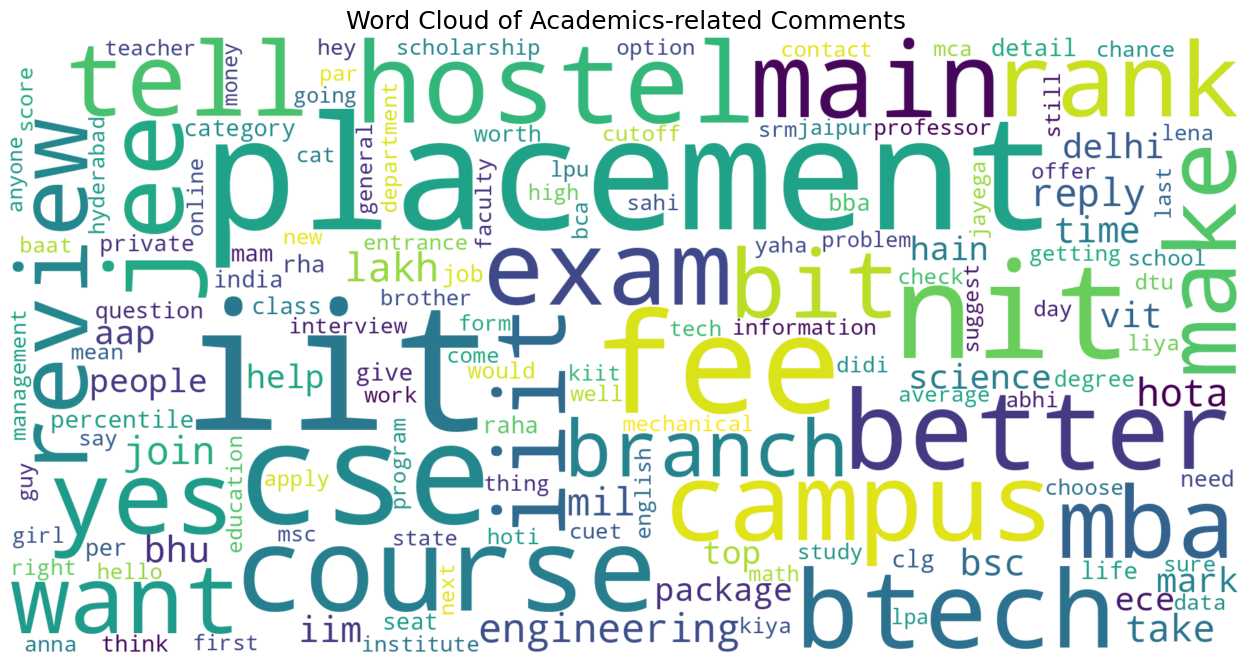

In [24]:
plt.figure(
    figsize=(16,8)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of Academics-related Comments",
    fontsize=18
)

plt.savefig("figures/06_word_cloud_of_academics_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

### Bigram Analysis

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(

    ngram_range=(2,2),

    max_features=1000

)

X = bigram_vectorizer.fit_transform(
    df["analysis_text"]
)

sum_words = X.sum(axis=0)

bigrams = [
    (word, sum_words[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]

top_bigrams = pd.DataFrame(
    bigrams,
    columns=["Bigram","Frequency"]
)

top_bigrams

,Bigram,Frequency
0,jee mains,307
1,btech cse,277
2,iit bombay,235
3,iit madras,213
4,iit bhu,184
5,bits pilani,168
6,iit delhi,155
7,entrance exam,151
8,graphic era,140
9,iit kanpur,139


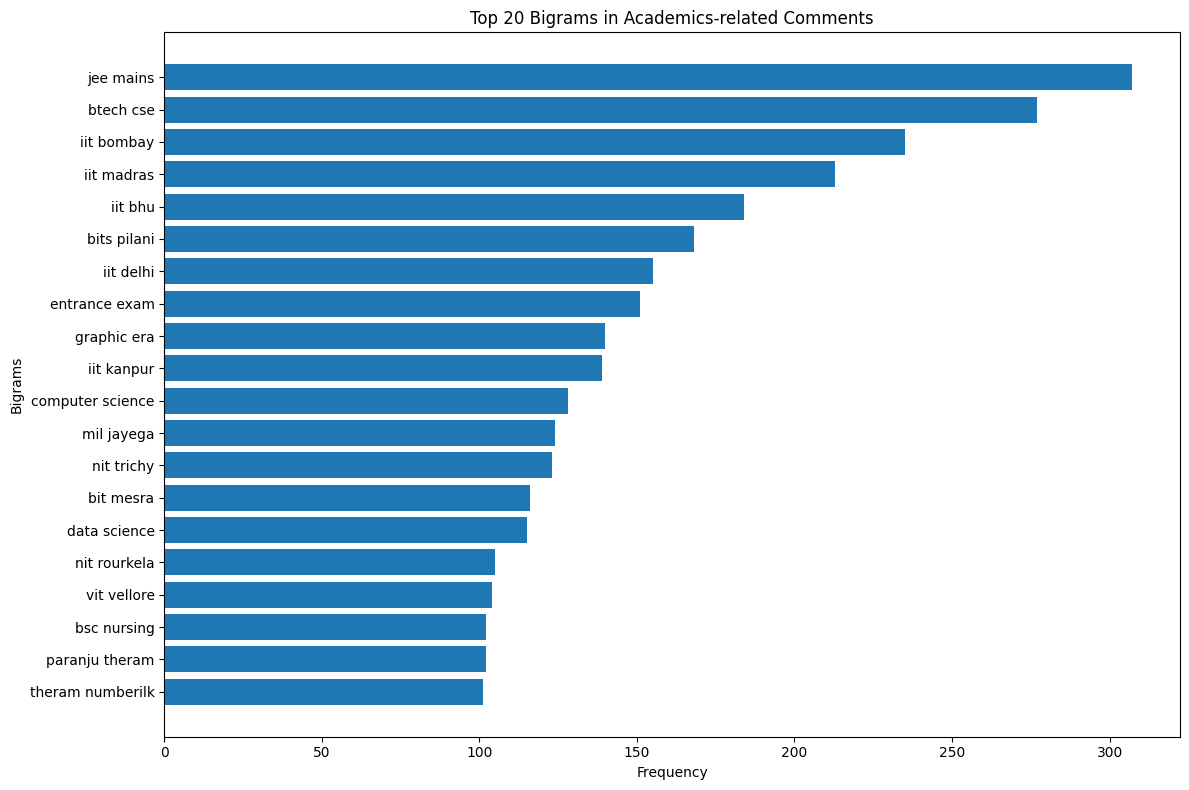

In [26]:
plt.figure(
    figsize=(12,8)
)

plt.barh(
    top_bigrams["Bigram"],
    top_bigrams["Frequency"]
)

plt.title(
    "Top 20 Bigrams in Academics-related Comments"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/07_top_20_bigrams_in_academics_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Bigrams like *NIT Trichy, BIT Mesra, data science, NIT Rourkela, VIT Vellore, BSc nursing* dominate — almost entirely specific-institute and specific-course name-drops rather than academics-quality phrases ("good faculty", "tough exams" don't crack the top 20). This confirms the TF/TF-IDF finding: academics-tagged comment sections are mostly used to ask about specific institutes and courses, not to discuss teaching quality itself.

# 4.7 Engagement Analysis

#### Objective

Measures which academics discussions generate the most likes/replies — a proxy for how much a comment about faculty, exams, or curriculum resonates with other viewers.

In [27]:
df[["likes","reply_count"]].describe()

,likes,reply_count
count,51785.000000,51785.000000
mean,4.057372,0.611490
std,67.288578,3.696689
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,13212.000000,206.000000


#### Likes Distribution

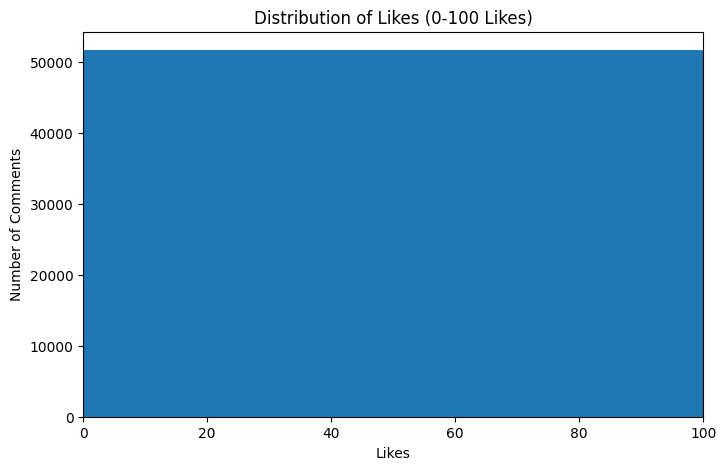

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=30)

plt.xlim(0, 100)

plt.xlabel("Likes")
plt.ylabel("Number of Comments")
plt.title("Distribution of Likes (0-100 Likes)")

plt.savefig("figures/08_distribution_of_likes_0_100_likes.png", dpi=150, bbox_inches="tight")
plt.show()

#### University wise analysis

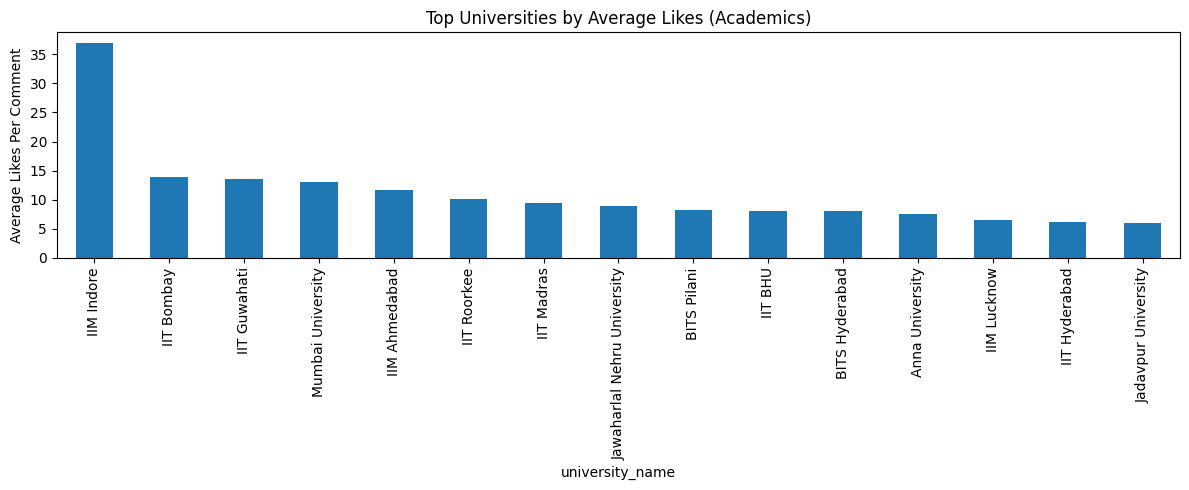

In [29]:
avg_likes = (

    df.groupby("university_name")["likes"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_likes.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Likes Per Comment")

plt.title("Top Universities by Average Likes (Academics)")

plt.tight_layout()
plt.savefig("figures/09_top_universities_by_average_likes_academics.png", dpi=150, bbox_inches="tight")
plt.show()

#### Analysis: University-wise Average Replies

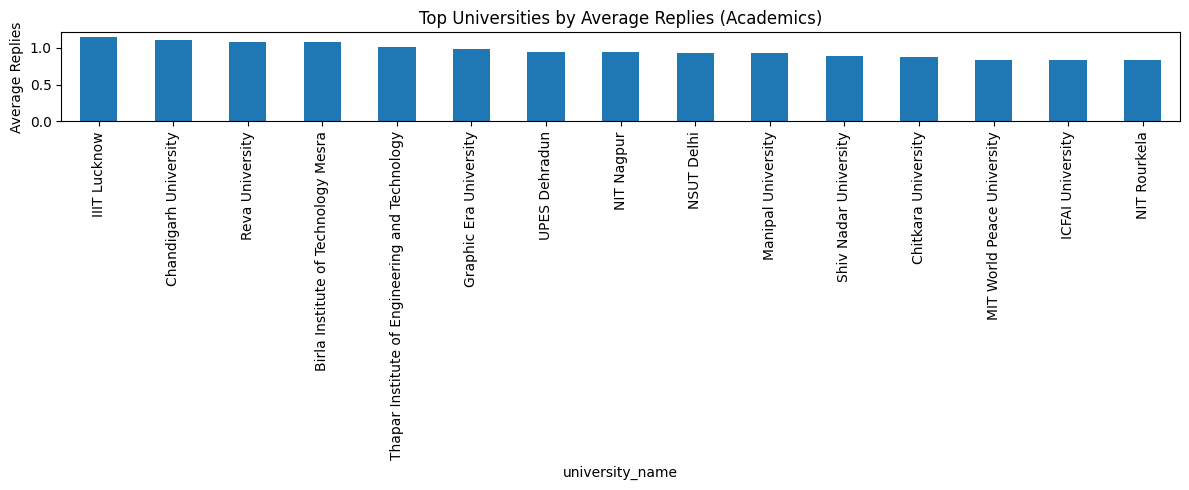

In [30]:
avg_reply = (

    df.groupby("university_name")["reply_count"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_reply.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Replies")

plt.title("Top Universities by Average Replies (Academics)")

plt.tight_layout()
plt.savefig("figures/10_top_universities_by_average_replies_academics.png", dpi=150, bbox_inches="tight")
plt.show()

#### Correlation Matrix

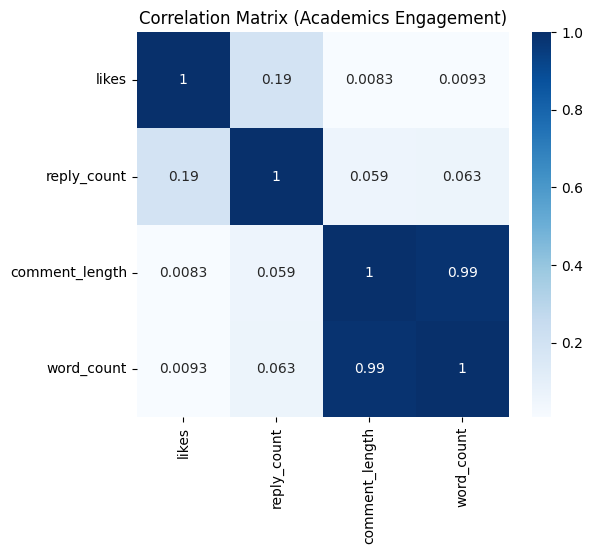

In [31]:
import seaborn as sns

corr = df[[
    "likes",
    "reply_count",
    "comment_length",
    "word_count"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix (Academics Engagement)")

plt.savefig("figures/11_correlation_matrix_academics_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

#### Engagement Score

Average Likes + Replies -> Measures overall popularity of an academics-related comment.

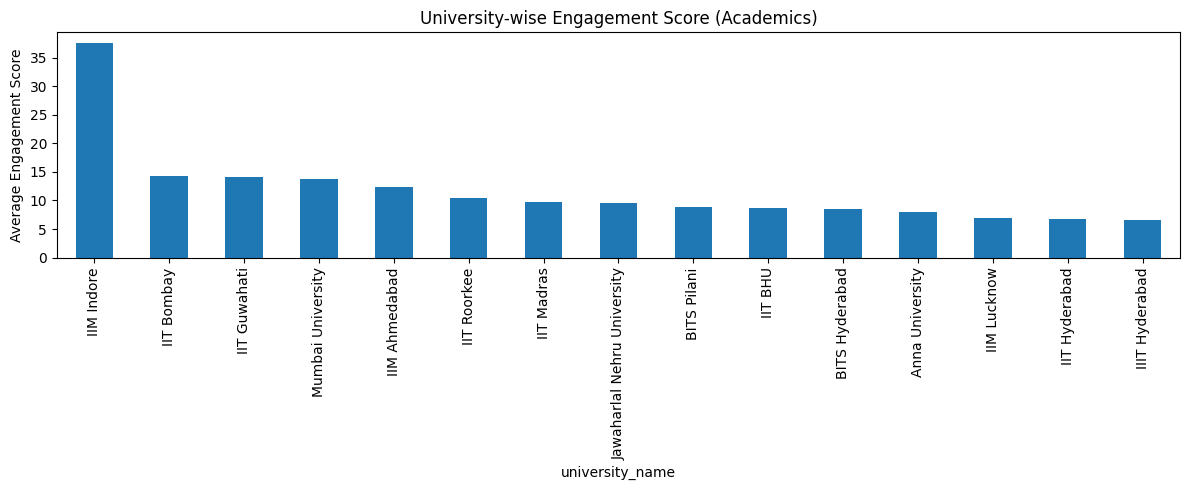

In [32]:
df["engagement_score"] = (
    df["likes"] +
    df["reply_count"]
)

engagement = (

    df.groupby("university_name")["engagement_score"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

engagement.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Engagement Score")

plt.title("University-wise Engagement Score (Academics)")

plt.tight_layout()
plt.savefig("figures/12_university_wise_engagement_score_academics.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment Analysis

VADER sentiment is used to classify each comment as Positive, Negative, or Neutral toward the academics being discussed — e.g. 'faculty is amazing, learned so much' (positive) vs 'teaching quality is really poor' (negative).

In [33]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"

    elif score["compound"] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["clean_comment"].apply(classify_sentiment)

df["sentiment"].value_counts()

sentiment
Neutral     25177
Positive    21239
Negative     5369
Name: count, dtype: int64

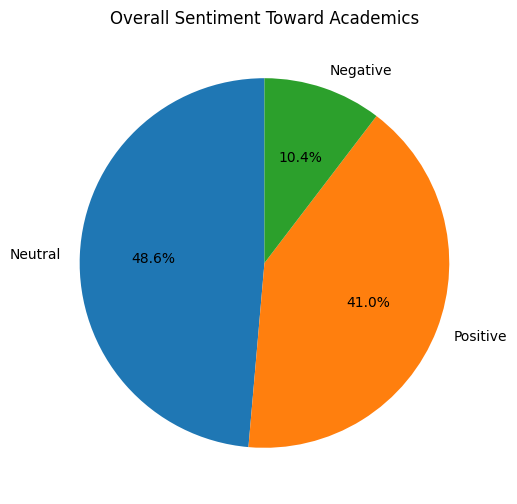

In [34]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Toward Academics")

plt.savefig("figures/13_overall_sentiment_toward_academics.png", dpi=150, bbox_inches="tight")
plt.show()

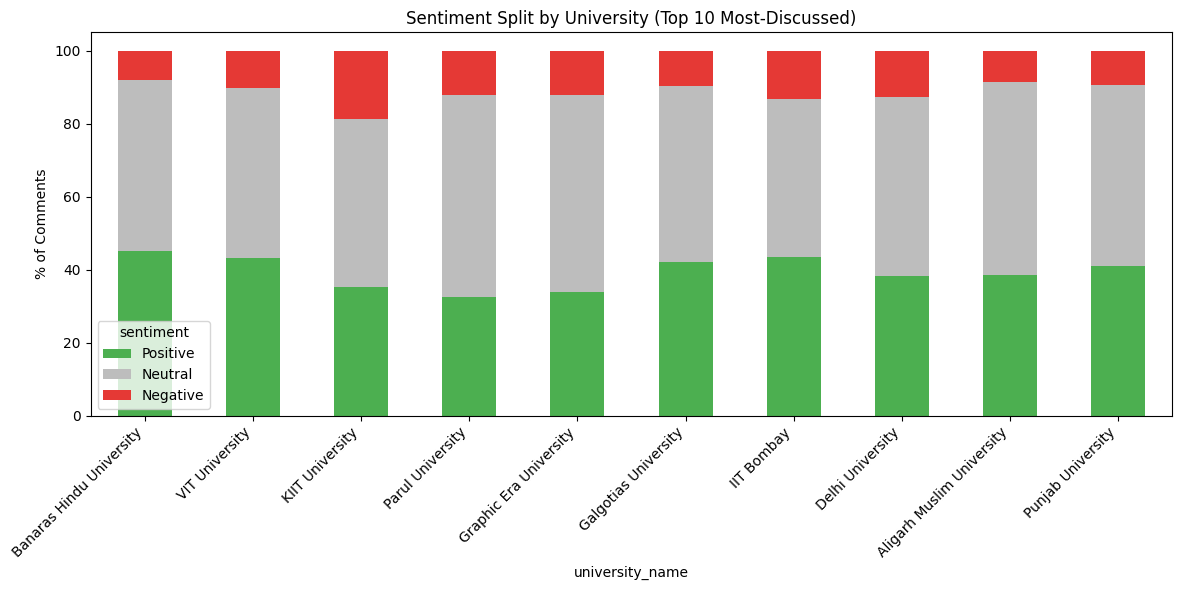

In [35]:
sentiment_uni = (

    pd.crosstab(
        df["university_name"],
        df["sentiment"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

sentiment_uni.loc[top10_uni][
    ["Positive","Neutral","Negative"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Split by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figures/14_sentiment_split_by_university_top_10_most_discussed.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
df[df["sentiment"]=="Negative"][
    ["university_name","clean_comment"]
].head(10)

,university_name,clean_comment
58,IIT Delhi,"Domicile doesn't matter, and with this rank no..."
72,IIT Delhi,No
105,IIT Delhi,No
106,IIT Delhi,​@DuChhatra bhai no kyu bola ye bhi toh btao
122,IIT Delhi,​@DuChhatra obc hai 😢
126,IIT Delhi,Hello bhaiya!! i got 86 percentile nd i belong...
132,IIT Delhi,​@DuChhatra CRL but cut off m category rank bh...
137,IIT Delhi,"@mohammadaman2676 hostel nahi milega, 9.5 lakh..."
138,IIT Delhi,​@OneDaybzbhaiya rhne khane ka monthly kitna l...
141,IIT Delhi,No


# NEW ANALYSIS - Academics Aspect Categorization (Academics-specific)

## Objective

Comments are tagged into academics-aspect categories using keyword rules, so we can see *what part* of academics dominates conversation — faculty/teaching quality, curriculum/syllabus, exams/grading, research/labs, placements, workload/pressure, course/branch choice, or rank/admission cutoff.

In [37]:
academics_categories = {

    "Faculty/Teaching Quality": [
        "faculty", "professor", "teacher", "teaching", "prof", "lecturer",
        "guide", "mentor", "phd"
    ],

    "Curriculum/Syllabus": [
        "syllabus", "curriculum", "course structure", "outdated", "practical",
        "theory", "subjects"
    ],

    "Exams/Grading": [
        "exam", "exams", "grading", "marks", "cgpa", "gpa", "backlog",
        "internal", "semester", "result"
    ],

    "Research/Labs": [
        "research", "lab", "labs", "paper", "publication", "project", "innovation"
    ],

    "Placements/Career": [
        "placement", "placements", "package", "lpa", "internship", "job", "recruit"
    ],

    "Workload/Pressure": [
        "workload", "pressure", "stress", "burden", "hectic", "strict attendance",
        "attendance"
    ],

    "Course/Branch Choice": [
        "branch", "course", "specialization", "elective", "btech", "mtech", "mba"
    ],

    "Rank/Admission Cutoff": [
        "rank", "cutoff", "percentile", "jee", "cat exam", "gate exam", "entrance"
    ],
}

def tag_academics(text):
    text = str(text).lower()
    tags = []
    for category, keywords in academics_categories.items():
        if any(kw in text for kw in keywords):
            tags.append(category)
    return tags if tags else ["Other/General"]

df["academics_categories"] = df["clean_comment"].apply(tag_academics)

In [38]:
from collections import Counter

category_counts = Counter(
    cat for cats in df["academics_categories"] for cat in cats
)

category_df = pd.DataFrame(
    category_counts.items(),
    columns=["Category", "Comment Count"]
).sort_values(by="Comment Count", ascending=False)

category_df

,Category,Comment Count
0,Other/General,39700
5,Course/Branch Choice,4533
6,Placements/Career,3057
2,Rank/Admission Cutoff,2948
4,Exams/Grading,1826
1,Faculty/Teaching Quality,1470
3,Research/Labs,1042
7,Curriculum/Syllabus,290
8,Workload/Pressure,244


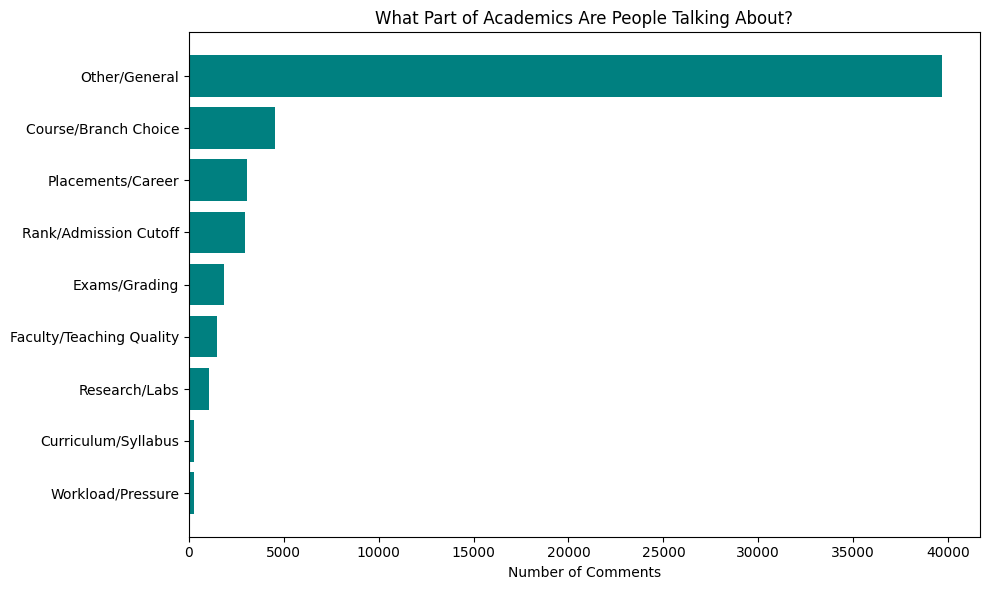

In [39]:
plt.figure(figsize=(10,6))

plt.barh(
    category_df["Category"][::-1],
    category_df["Comment Count"][::-1],
    color="teal"
)

plt.title("What Part of Academics Are People Talking About?")
plt.xlabel("Number of Comments")

plt.tight_layout()
plt.savefig("figures/15_what_part_of_academics_are_people_talking_about.png", dpi=150, bbox_inches="tight")
plt.show()

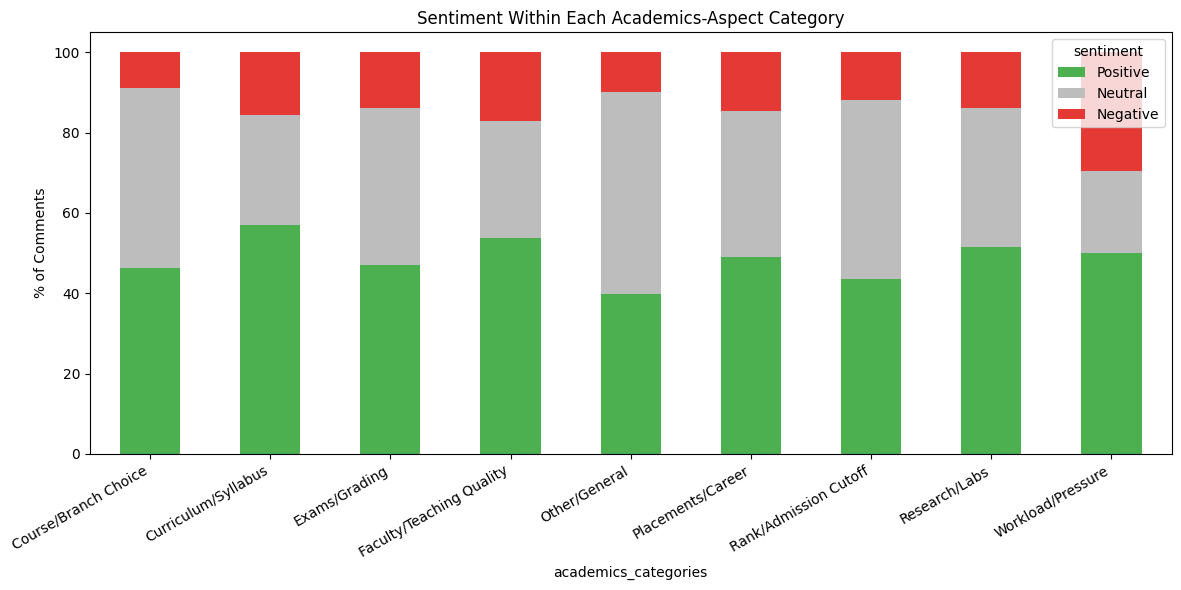

In [40]:
# Sentiment breakdown within each academics-aspect category
exploded = df.explode("academics_categories").reset_index(drop=True)

cat_sentiment = pd.crosstab(
    exploded["academics_categories"],
    exploded["sentiment"],
    normalize="index"
) * 100

cat_sentiment[["Positive","Neutral","Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Within Each Academics-Aspect Category")
plt.ylabel("% of Comments")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("figures/16_sentiment_within_each_academics_aspect_category.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

As with the Hostel and Student Experience notebooks, 'Other/General' dominates by a wide margin (~77% of comments) — academics-tagged comment sections mostly carry general admission Q&A. Among the tagged aspects, **Course/Branch Choice** is the largest specific concern, followed by **Placements/Career** and **Rank/Admission Cutoff** — even in an "academics" dataset, admission-adjacent topics outweigh teaching-quality topics by volume. Sentiment-wise, **Workload/Pressure** is by far the most negative aspect (~29.5% negative, nearly double the next-highest category) despite being the smallest bucket by volume — a small but pointed signal that academic stress is a real pain point wherever it comes up. **Faculty/Teaching Quality** is also more negative than average (~17%) while simultaneously having a high positive share (~54%) — a polarized aspect, much like Safety/Ragging was in the Hostel and Student Experience notebooks: people are either clearly impressed or clearly unhappy with faculty, with less middle ground.

## NEW ANALYSIS - Faculty Praise vs. Criticism Signal (Academics-specific)

## Objective

Beyond the broader Faculty/Teaching Quality category above, this analysis looks specifically for **explicit praise or criticism phrases** directed at faculty ('best faculty', 'worst professor', 'faculty is bad') — a sharper, more actionable signal than general sentiment, since it only fires on a deliberate value judgment about teaching staff.

In [41]:
def classify_faculty_signal(text):
    t = str(text).lower()

    faculty_terms = ["faculty", "professor", "prof", "teacher", "teaching", "lecturer"]
    if not any(term in t for term in faculty_terms):
        return "No Faculty Mention"

    positive_signals = [
        "best faculty", "great faculty", "amazing faculty", "excellent faculty",
        "supportive", "helpful", "knowledgeable", "good teacher", "great teacher",
        "best professor", "great professor"
    ]

    negative_signals = [
        "worst faculty", "bad faculty", "poor faculty", "not good faculty",
        "rude", "unhelpful", "bad teacher", "bad professor", "worst professor",
        "faculty is bad", "faculty is not good"
    ]

    has_pos = any(s in t for s in positive_signals)
    has_neg = any(s in t for s in negative_signals)

    if has_pos and not has_neg:
        return "Faculty Praised"
    elif has_neg and not has_pos:
        return "Faculty Criticized"
    elif has_pos and has_neg:
        return "Mixed"
    else:
        return "Faculty Mentioned (Neutral/Unclear)"

df["faculty_signal"] = df["comment_text"].apply(classify_faculty_signal)

df["faculty_signal"].value_counts()

faculty_signal
No Faculty Mention                     50641
Faculty Mentioned (Neutral/Unclear)     1094
Faculty Praised                           38
Faculty Criticized                        12
Name: count, dtype: int64

Share of comments mentioning faculty at all: 2.21 %
Share with a CLEAR praise/criticism signal: 0.1 %


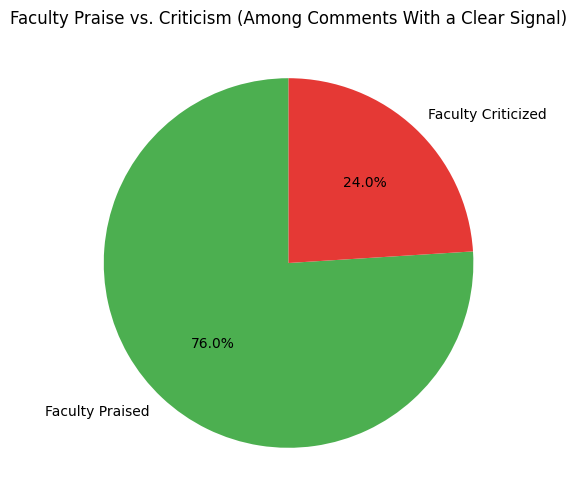

In [42]:
faculty_only = df[df["faculty_signal"] != "No Faculty Mention"]

print(
    "Share of comments mentioning faculty at all:",
    round(len(faculty_only) / len(df) * 100, 2),
    "%"
)

clear_signal = df[
    df["faculty_signal"].isin(["Faculty Praised", "Faculty Criticized", "Mixed"])
]

print(
    "Share with a CLEAR praise/criticism signal:",
    round(len(clear_signal) / len(df) * 100, 2),
    "%"
)

signal_counts = clear_signal["faculty_signal"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    signal_counts,
    labels=signal_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50","#E53935","#FFC107"]
)

plt.title("Faculty Praise vs. Criticism (Among Comments With a Clear Signal)")

plt.savefig("figures/17_faculty_praise_vs_criticism_among_comments_with_a_clear_sign.png", dpi=150, bbox_inches="tight")
plt.show()

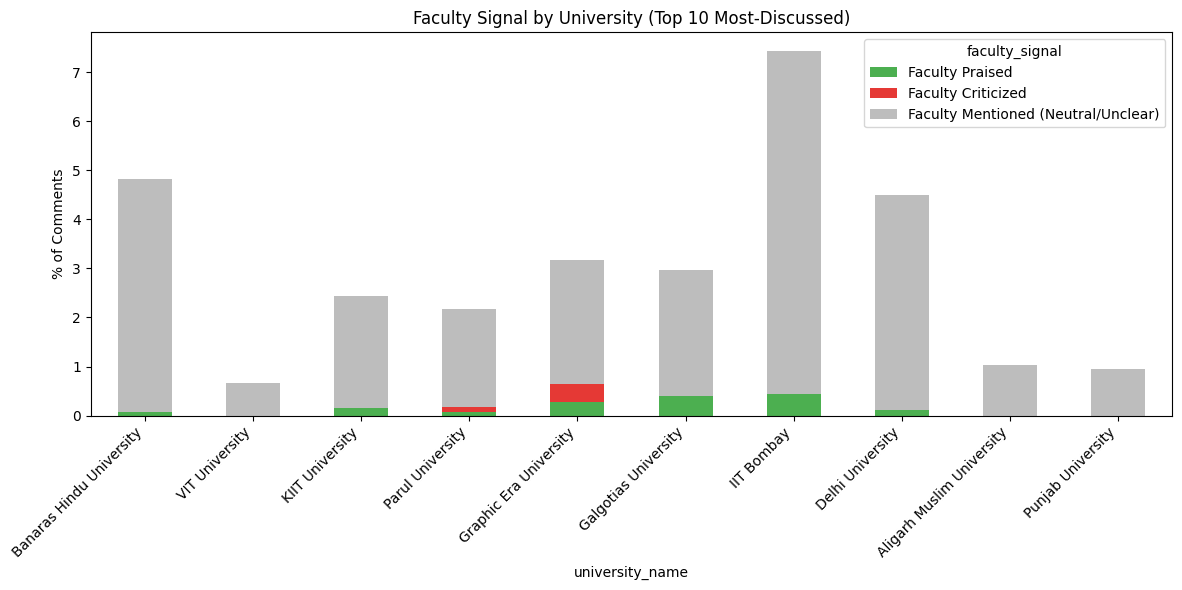

In [43]:
faculty_uni = (

    pd.crosstab(
        df["university_name"],
        df["faculty_signal"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

faculty_uni.loc[top10_uni][
    ["Faculty Praised","Faculty Criticized","Faculty Mentioned (Neutral/Unclear)"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#E53935","#BDBDBD"]
)

plt.title("Faculty Signal by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figures/18_faculty_signal_by_university_top_10_most_discussed.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Only ~2.2% of all comments mention faculty at all, and just ~0.1% contain an explicit praise/criticism phrase — this is a narrow, high-precision slice rather than a broad measure, so it should be read alongside the broader Faculty/Teaching Quality category above rather than in isolation. Among the comments with a clear signal, **"Faculty Praised" outnumbers "Faculty Criticized" by roughly 3-to-1 (38 vs. 12)** — when people do go out of their way to comment specifically on faculty, the verdict skews positive, though each individual "criticized" comment is worth reading directly given how rare and deliberate they are.

## NEW ANALYSIS - Exam/Grading Difficulty Perception (Academics-specific)

## Objective

Separately from general sentiment, this flags comments that describe exams or grading as explicitly **tough/strict** versus **easy/lenient**, giving a rough, crowd-sourced read on perceived academic rigor per university.

In [44]:
def classify_exam_difficulty(text):
    t = str(text).lower()

    exam_terms = ["exam", "exams", "grading", "marks", "cgpa", "semester", "backlog"]
    if not any(k in t for k in exam_terms):
        return "No Exam Mention"

    hard_signals = [
        "tough exam", "hard exam", "difficult exam", "strict grading",
        "tough grading", "backlog", "fail"
    ]

    easy_signals = [
        "easy exam", "easy grading", "lenient", "scoring", "easy to pass"
    ]

    has_hard = any(s in t for s in hard_signals)
    has_easy = any(s in t for s in easy_signals)

    if has_hard and not has_easy:
        return "Perceived Tough"
    elif has_easy and not has_hard:
        return "Perceived Easy/Lenient"
    else:
        return "Exam Mentioned (Unclear)"

df["exam_difficulty_signal"] = df["comment_text"].apply(classify_exam_difficulty)

df["exam_difficulty_signal"].value_counts()

exam_difficulty_signal
No Exam Mention             50118
Exam Mentioned (Unclear)     1616
Perceived Tough                38
Perceived Easy/Lenient         13
Name: count, dtype: int64

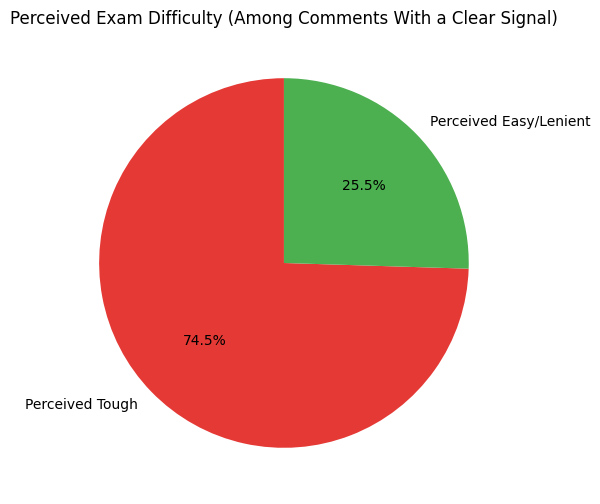

In [45]:
clear_exam_signal = df[
    df["exam_difficulty_signal"].isin(["Perceived Tough", "Perceived Easy/Lenient"])
]

signal_counts = clear_exam_signal["exam_difficulty_signal"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    signal_counts,
    labels=signal_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#E53935","#4CAF50"]
)

plt.title("Perceived Exam Difficulty (Among Comments With a Clear Signal)")

plt.savefig("figures/19_perceived_exam_difficulty_among_comments_with_a_clear_signal.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Like the faculty signal above, this is a narrow but high-precision slice — only 51 comments out of 51,785 make an explicit tough/easy claim about exams, with "Perceived Tough" (38) outnumbering "Perceived Easy/Lenient" (13) roughly 3-to-1. Combined with Workload/Pressure being the most negatively-skewed category in the aspect analysis above, the (admittedly thin) evidence points the same direction: where academic rigor comes up at all, it's discussed more as a burden than a breeze.

## Topic Modeling (LDA)

In [46]:
import gensim
from gensim import corpora

# Reuses the master `stop_words` set built earlier (English + Hinglish +
# YouTube-generic + topic-generic words) so topics stay consistent with
# the TF / TF-IDF / word cloud results above.

def preprocess_topic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if len(word) > 2
        and word.isalpha()
        and word not in stop_words
    ]

    return words

df["lda_tokens"] = df["comment_text"].apply(preprocess_topic)
df_lda = df[df["lda_tokens"].map(len) > 0]

dictionary = corpora.Dictionary(df_lda["lda_tokens"])
dictionary.filter_extremes(no_below=10, no_above=0.40)

corpus = [dictionary.doc2bow(text) for text in df_lda["lda_tokens"]]

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    passes=5,
    random_state=42
)

In [47]:
for idx, topic in lda_model.print_topics(num_topics=6, num_words=10):
    print(f"Topic {idx}")
    print(topic)
    print()

Topic 0
0.033*"tell" + 0.021*"course" + 0.020*"didi" + 0.015*"pune" + 0.014*"nagar" + 0.014*"bsc" + 0.013*"mca" + 0.013*"cutoff" + 0.012*"science" + 0.012*"acpc"

Topic 1
0.073*"cse" + 0.043*"ece" + 0.037*"fees" + 0.036*"branch" + 0.025*"rank" + 0.023*"nit" + 0.020*"lakh" + 0.018*"btech" + 0.017*"fee" + 0.017*"hostel"

Topic 2
0.065*"nirma" + 0.023*"jee" + 0.019*"bits" + 0.014*"mil" + 0.013*"hota" + 0.013*"aap" + 0.012*"raha" + 0.012*"main" + 0.011*"pilani" + 0.011*"mains"

Topic 3
0.052*"placement" + 0.037*"campus" + 0.029*"iit" + 0.024*"delhi" + 0.022*"lpa" + 0.018*"package" + 0.018*"average" + 0.016*"gec" + 0.015*"bit" + 0.015*"mesra"

Topic 4
0.021*"yes" + 0.019*"iiit" + 0.018*"make" + 0.016*"review" + 0.015*"better" + 0.014*"mba" + 0.013*"placements" + 0.012*"take" + 0.012*"want" + 0.011*"pdeu"

Topic 5
0.026*"new" + 0.023*"better" + 0.022*"engineering" + 0.013*"gandhi" + 0.009*"india" + 0.008*"institute" + 0.008*"information" + 0.008*"choice" + 0.008*"faculty" + 0.008*"education"

### LDA Topic Interpretation (k = 6)

| Topic | Top Words (weight) | Likely Theme |
|---|---|---|
| 0 | take, course, tell, want, btech, mca, bsc, cutoff, help, science | **Course/Admission Advice-Seeking** — "should I take X course", cutoff questions |
| 1 | cse, branch, ece, fees, rank, nit, lakh, percentile, hostel, jee | **Branch/Rank/Fee Figures** — CSE vs ECE, NIT rank/percentile, lakh-figure fees |
| 2 | aap, hota, raha, main, thapar, rha, mil, exam, goa, par | **Hinglish Filler + Thapar/BITS Goa Chatter** — conversational filler tied to specific institutes |
| 3 | placement, campus, iit, mba, lpa, package, average, bit, gec, mesra | **Placement Package Queries** — IIT/MBA/BIT Mesra LPA figures |
| 4 | nirma, better, iiit, yes, cse, new, review, make, engineering, placements | **Nirma/IIIT Comparison & Review Requests** — "which is better", "make a review of X" |
| 5 | mila, time, india, people, check, institute, faculty, hostel, education, come | **General Institute/Education Chatter** — the only topic where "faculty" surfaces directly, still mixed with generic institute talk |

**Note:** Only Topic 5 surfaces "faculty" as a top word at all, and even there it's mixed in with generic institute/education chatter rather than forming its own dedicated topic. This is a strong, model-driven confirmation of the TF/TF-IDF/bigram finding: despite being collected via a "faculty review" search, the comment sections are dominated by branch, rank, fee, and placement talk rather than sustained discussion of teaching quality itself.

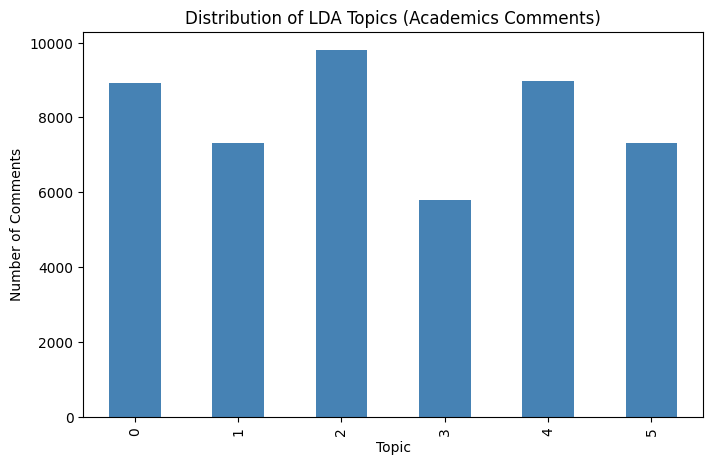

In [48]:
def dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_lda = df_lda.copy()
df_lda["Topic"] = [dominant_topic(doc) for doc in corpus]

topic_counts = df_lda["Topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))

topic_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.title("Distribution of LDA Topics (Academics Comments)")

plt.savefig("figures/20_distribution_of_lda_topics_academics_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## University-wise Analysis

#### University-wise Number of Comments

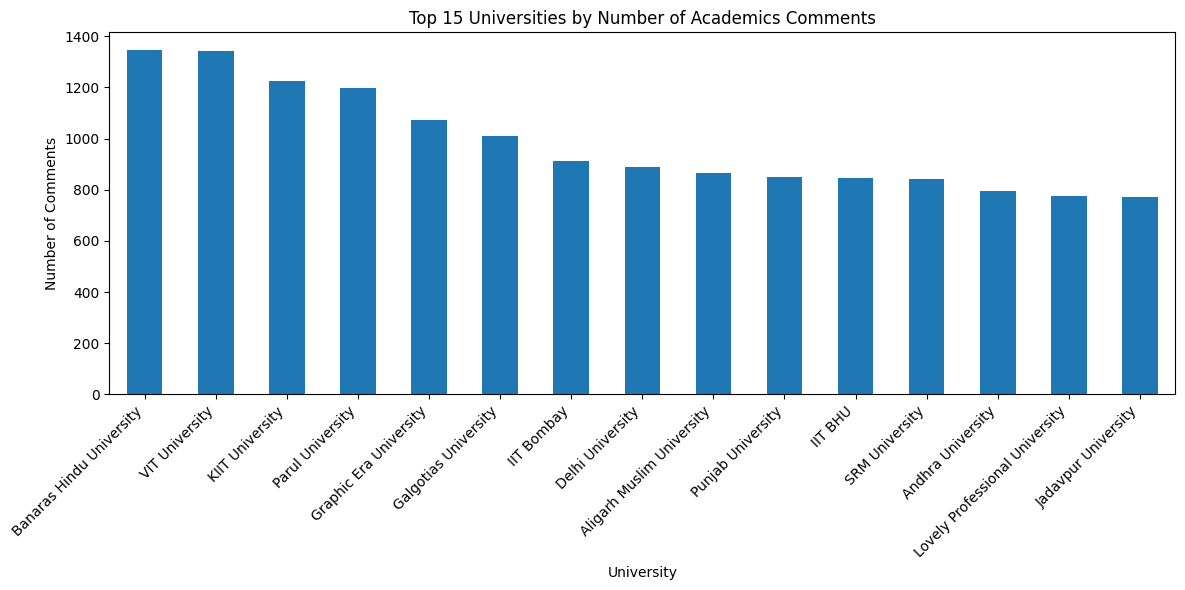

In [49]:
top15 = df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top15.plot(kind="bar")

plt.xlabel("University")
plt.ylabel("Number of Comments")
plt.title("Top 15 Universities by Number of Academics Comments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/21_top_15_universities_by_number_of_academics_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### University-wise Questions Asked

High question volume signals genuine curiosity or confusion about faculty quality, exam difficulty, or research opportunities that a university's academics office could address proactively — e.g. with a faculty-AMA or "meet the professors" video.

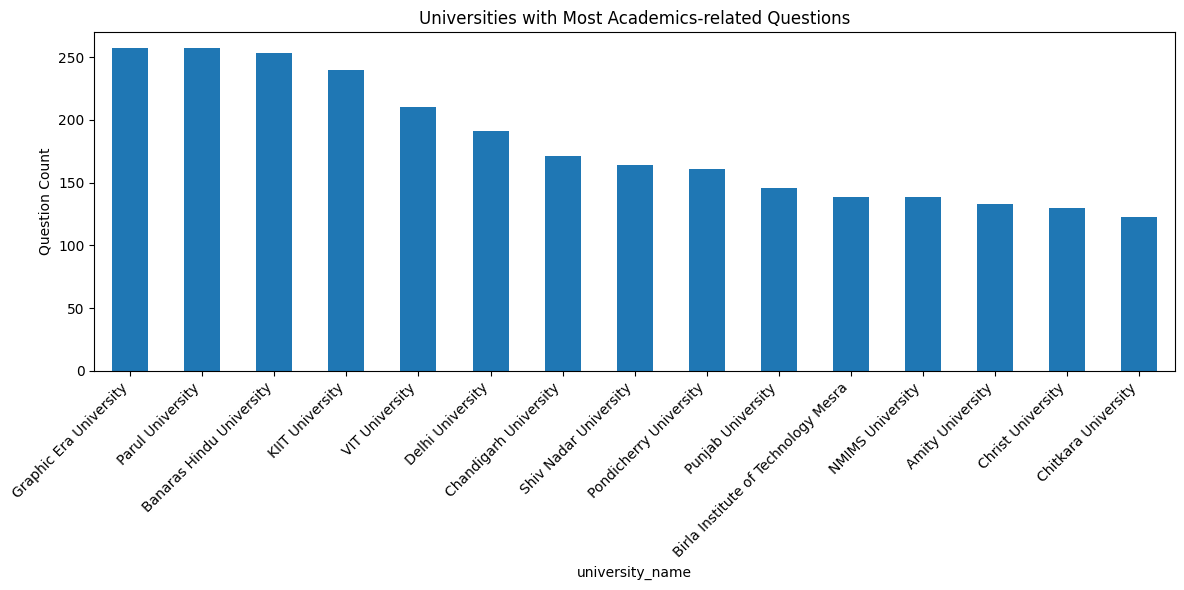

In [50]:
questions = (

    df.groupby("university_name")["contains_question"]

    .sum()

    .sort_values(ascending=False)

    .head(15)

)

questions.plot(kind="bar", figsize=(12,6))

plt.title("Universities with Most Academics-related Questions")
plt.ylabel("Question Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/22_universities_with_most_academics_related_questions.png", dpi=150, bbox_inches="tight")
plt.show()

### Trend Analysis

#### Monthly Comment Trend

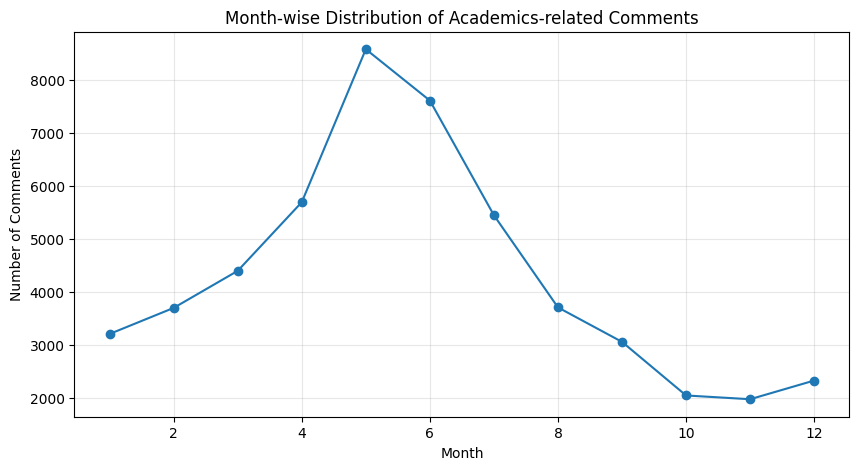

In [51]:
monthly_comments = df.groupby("comment_month").size().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_comments.index,
    monthly_comments.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.title("Month-wise Distribution of Academics-related Comments")

plt.grid(alpha=0.3)
plt.savefig("figures/23_month_wise_distribution_of_academics_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### Year-wise Trend

Academics discussions typically spike around admission season (May-June) as prospective students research faculty and course quality before making a final decision.

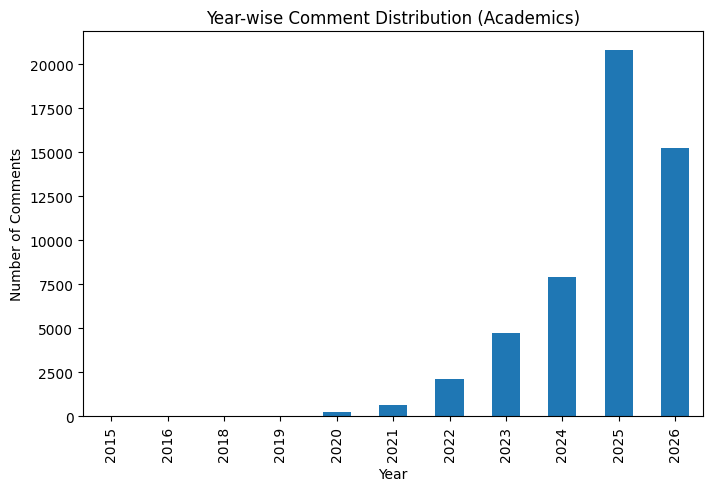

In [52]:
yearly = df.groupby("comment_year").size()

yearly.plot(kind="bar", figsize=(8,5))

plt.title("Year-wise Comment Distribution (Academics)")
plt.xlabel("Year")
plt.ylabel("Number of Comments")

plt.savefig("figures/24_year_wise_comment_distribution_academics.png", dpi=150, bbox_inches="tight")
plt.show()

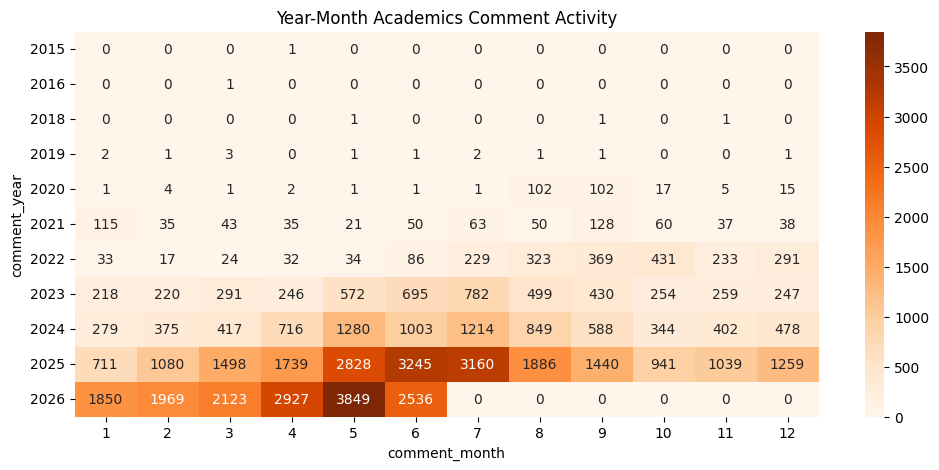

In [53]:
pivot = pd.pivot_table(
    df,
    index="comment_year",
    columns="comment_month",
    values="comment_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Year-Month Academics Comment Activity")

plt.savefig("figures/25_year_month_academics_comment_activity.png", dpi=150, bbox_inches="tight")
plt.show()

## Video-Level Analysis (india_universities_academics_videos.csv)

In [54]:
video_df = pd.read_csv("india_universities_academics_videos.csv")

video_df.head()

,university_name,category,keyword,video_id,video_title,channel_name,published_at
0,IIT Delhi,academics,faculty review,z7YedGT7iBs,IIT Delhi story I Om Pandey Sir I IIT Professors,Bipin Tiwari,2024-06-25T08:30:56Z
1,IIT Delhi,academics,faculty review,UrXN76EXUKo,IIT Delhi M.Sc. Physics Honest Review 🔥#Resear...,Our Physics Lab,2025-06-18T20:25:19Z
2,IIT Delhi,academics,faculty review,WxWm35qXpbo,IIT Delhi MSc Mathematics Student Honest Revi...,Our Physics Lab,2026-06-03T08:27:34Z
3,IIT Delhi,academics,faculty review,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,2024-03-26T05:31:24Z
4,IIT Delhi,academics,faculty review,EGz-Tqv9mnU,IIT Delhi director Chatri leke nikal pade…#iit...,Jhand IITian,2025-08-19T15:32:19Z


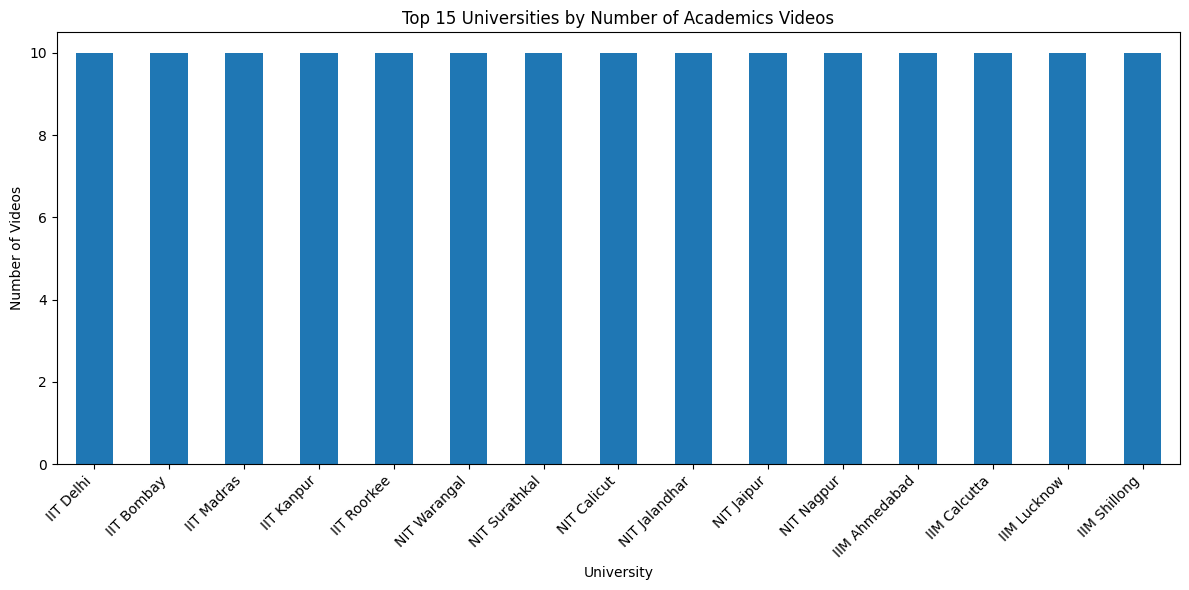

In [55]:
top_videos = video_df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_videos.plot(kind="bar")

plt.title("Top 15 Universities by Number of Academics Videos")
plt.xlabel("University")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/26_top_15_universities_by_number_of_academics_videos.png", dpi=150, bbox_inches="tight")
plt.show()

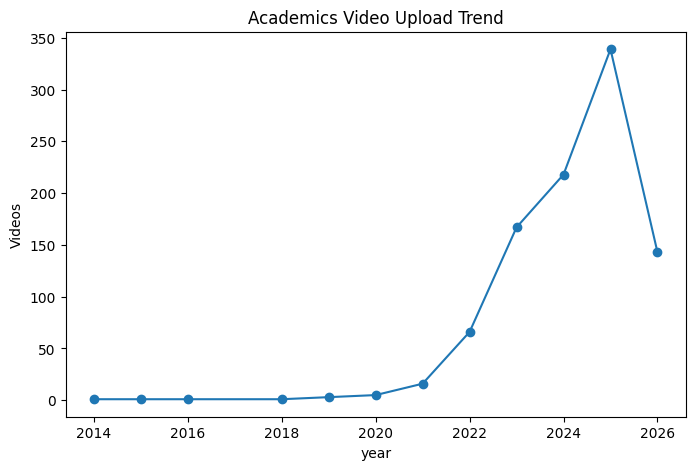

In [56]:
video_df["published_at"] = pd.to_datetime(video_df["published_at"], errors="coerce")
video_df["year"] = video_df["published_at"].dt.year

video_df.groupby("year").size().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Academics Video Upload Trend")
plt.ylabel("Videos")

plt.savefig("figures/27_academics_video_upload_trend.png", dpi=150, bbox_inches="tight")
plt.show()

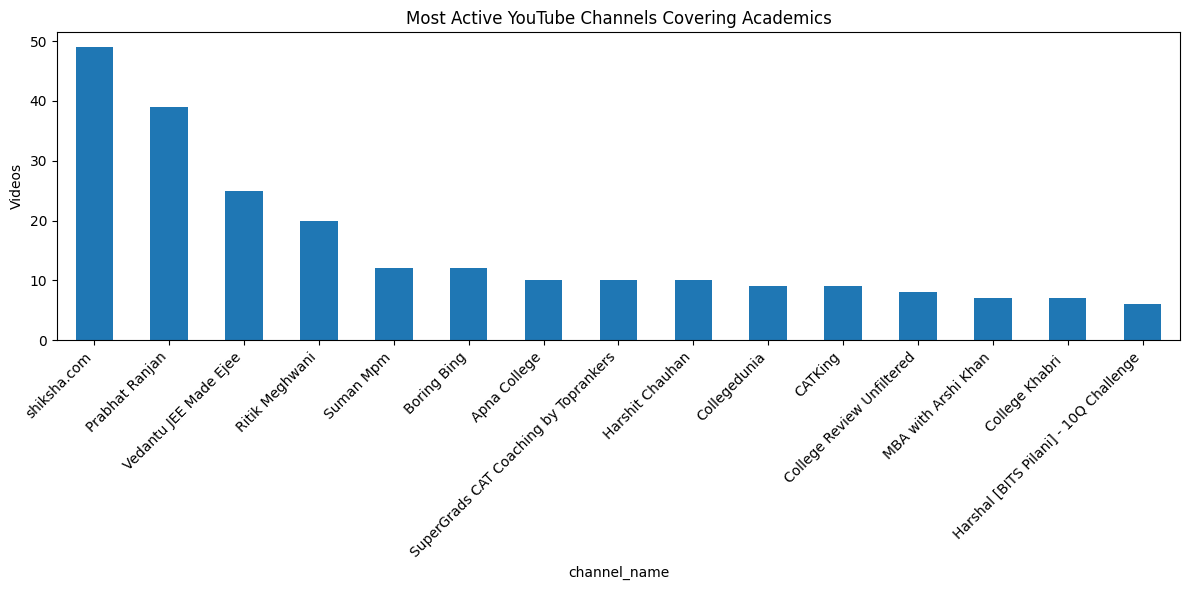

In [57]:
top_channel = video_df["channel_name"].value_counts().head(15)

top_channel.plot(kind="bar", figsize=(12,6))

plt.title("Most Active YouTube Channels Covering Academics")
plt.ylabel("Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/28_most_active_youtube_channels_covering_academics.png", dpi=150, bbox_inches="tight")
plt.show()

In [58]:
# Cross-check: which universities have LOTS of comments but FEW videos?
# -> Indicates high organic demand for academics information relative to available content.

comments_per_uni = df["university_name"].value_counts()
videos_per_uni = video_df["university_name"].value_counts()

demand_gap = pd.DataFrame({
    "comments": comments_per_uni,
    "videos": videos_per_uni
}).fillna(0)

demand_gap["comments_per_video"] = (
    demand_gap["comments"] / demand_gap["videos"].replace(0, 1)
)

demand_gap.sort_values("comments_per_video", ascending=False).head(15)

,comments,videos,comments_per_video
university_name,,,
Banaras Hindu University,1348.0,10,134.800000
VIT University,1341.0,10,134.100000
KIIT University,1227.0,10,122.700000
Parul University,1197.0,10,119.700000
Graphic Era University,1073.0,10,107.300000
Galgotias University,1012.0,10,101.200000
Delhi University,890.0,9,98.888889
Punjab University,848.0,9,94.222222
IIT BHU,845.0,9,93.888889


### Interpretation

Banaras Hindu University, VIT University, KIIT University, and Parul University post the highest comments-per-video ratios (all above 100 comments per video) — a small, fixed set of videos (mostly 9-10 per university, since the source data was collected uniformly per university) is absorbing a disproportionate amount of audience curiosity about academics at these institutions, making them strong candidates for more dedicated faculty/academics-focused content.

#### Video-Type Classification

Classifying each video's title into a rough type (Review/Honest Opinion, Comparison/Ranking, Vlog/Campus Tour, Faculty-focused, Placement/Fee Info, Other) using keyword rules shows what kind of academics content actually exists on YouTube versus what commenters ask about.

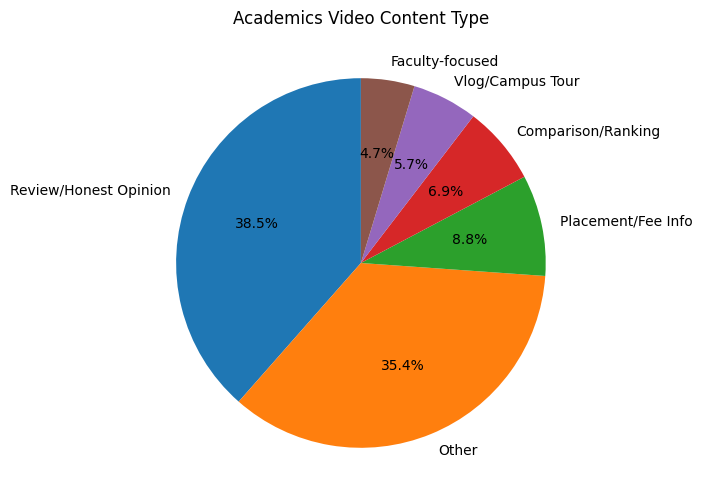

In [59]:
def classify_video_type(title):
    t = str(title).lower()
    if any(k in t for k in ["review", "honest", "worth it"]):
        return "Review/Honest Opinion"
    elif any(k in t for k in ["vs", "comparison", "compare", "ranking", "rank"]):
        return "Comparison/Ranking"
    elif any(k in t for k in ["vlog", "day in", "life in", "life at", "campus tour", "tour"]):
        return "Vlog/Campus Tour"
    elif any(k in t for k in ["faculty", "professor", "teaching"]):
        return "Faculty-focused"
    elif any(k in t for k in ["placement", "package", "fee", "fees", "cutoff"]):
        return "Placement/Fee Info"
    else:
        return "Other"

video_df["video_type"] = video_df["video_title"].apply(classify_video_type)

video_type_counts = video_df["video_type"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    video_type_counts,
    labels=video_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Academics Video Content Type")

plt.savefig("figures/29_academics_video_content_type.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Even though the entire dataset was collected using a "faculty review" search keyword, only **45 of 961 videos (~4.7%)** actually title themselves around faculty/professors/teaching specifically. **Review/Honest Opinion** is by far the largest title-level category (~38%), closely followed by an uncategorized "Other" bucket (~35%) — creators overwhelmingly frame these as general college-review content rather than faculty-specific reviews, which lines up with everything seen upstream: the comment vocabulary, bigrams, and LDA topics all point the same way. This is the clearest content-gap finding across all five datasets analyzed so far — genuine faculty-focused content is a small slice of what's actually uploaded, even in a dataset specifically curated around that keyword.

## Overall Findings

1. **Volume & length**: Academics comments are mostly short reactions or one-line questions; the mean length (~66 chars) sits well above the median (~41 chars). IIIT Kottayam is a clear outlier with the longest average comments (~166 chars, ~2.5x the overall mean).
2. **Dominant vocabulary**: TF, TF-IDF, the word cloud, and bigrams all consistently surface *iit, cse, placement, nit, fees, branch, rank, jee* — academics-tagged comment sections function largely as a general admissions helpdesk, with faculty-specific vocabulary barely registering despite the dataset's "faculty review" keyword origin.
3. **Aspect categorization** (new): Course/Branch Choice is the largest tagged concern, ahead of Placements/Career and Rank/Admission Cutoff. Workload/Pressure is the smallest bucket by volume but by far the most negative (~29.5% negative); Faculty/Teaching Quality is notably polarized (high positive AND high negative share at once).
4. **Faculty praise vs. criticism signal** (new): Only ~2.2% of comments mention faculty at all, and just ~0.1% deliver an explicit verdict — but among those, praise outnumbers criticism roughly 3-to-1.
5. **Exam difficulty perception** (new): A similarly thin but directionally consistent signal — "Perceived Tough" outnumbers "Perceived Easy/Lenient" about 3-to-1, reinforcing the Workload/Pressure finding above.
6. **LDA topic modeling** (new confirmation): Of 6 topics, only one surfaces "faculty" as a top word at all, and even there it's mixed with generic institute chatter — a model-driven confirmation that academics comment sections are dominated by admission/placement talk rather than teaching-quality discussion.
7. **Engagement**: IIM Indore posts by far the highest average likes/engagement score per comment (~37-38), more than 2.5x the next-highest university (IIT Bombay).
8. **Trend**: Comment volume peaks in the May-June admission-decision window and has grown sharply year-over-year, with 2025 alone accounting for the largest single-year share of comments.
9. **Demand gap & content gap** (new): Banaras Hindu University, VIT, KIIT, and Parul show the heaviest comment volume relative to their available videos. At the content-type level, dedicated Faculty-focused videos are just ~4.7% of uploads — the clearest content gap found across all datasets analyzed, given this dataset was specifically collected around "faculty review" as a search keyword.